In [5]:
!pip install xlrd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#IMPORT DU FICHIER

In [6]:
data = pd.read_excel('Downloads/titanic3.xls')

In [8]:
data.shape

(1309, 14)

In [9]:
data.columns

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')

In [10]:
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [11]:
data = data.drop(['name', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'], axis=1)

In [12]:
data.head()

,pclass,survived,sex,age
0,1,1,female,29.0000
1,1,1,male,0.9167
2,1,0,female,2.0000
3,1,0,male,30.0000
4,1,0,female,25.0000


In [13]:
data.describe()

,pclass,survived,age
count,1309.000000,1309.000000,1046.000000
mean,2.294882,0.381971,29.881135
std,0.837836,0.486055,14.413500
min,1.000000,0.000000,0.166700
25%,2.000000,0.000000,21.000000
50%,3.000000,0.000000,28.000000
75%,3.000000,1.000000,39.000000
max,3.000000,1.000000,80.000000


In [14]:
data  = data.dropna(axis=0)

In [15]:
data.shape

(1046, 4)

In [16]:
data.describe()

,pclass,survived,age
count,1046.000000,1046.000000,1046.000000
mean,2.207457,0.408222,29.881135
std,0.841497,0.491740,14.413500
min,1.000000,0.000000,0.166700
25%,1.000000,0.000000,21.000000
50%,2.000000,0.000000,28.000000
75%,3.000000,1.000000,39.000000
max,3.000000,1.000000,80.000000


# nombre de passagers du titanic par classe

In [17]:
data['pclass'].value_counts()

pclass
3    501
1    284
2    261
Name: count, dtype: int64

# graphique 

<Axes: xlabel='pclass'>

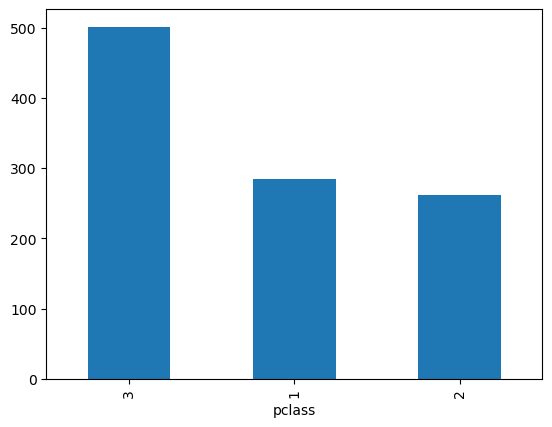

In [18]:
data['pclass'].value_counts().plot.bar()

# grouper par sexe(moyenne)

In [19]:
data.groupby(['sex']).mean()

,pclass,survived,age
sex,,,
female,2.048969,0.752577,28.687071
male,2.300912,0.205167,30.585233


# interpretation:

75% des femmes ont survecu, seulement 20% des hommes ont survecu. les femmes ayant survecu avaient en moyenne 28 ans , les hommes ayant survecu avaient 30 ans comme age moyenne

In [20]:
data.groupby(['sex','pclass']).mean()

survived        age
sex    pclass                     
female 1       0.962406  37.037594
       2       0.893204  27.499191
       3       0.473684  22.185307
male   1       0.350993  41.029250
       2       0.145570  30.815401
       3       0.169054  25.962273

# selection des passagers mineurs

In [21]:
data['age']<18

0       False
1        True
2        True
3       False
4       False
        ...  
1301    False
1304     True
1306    False
1307    False
1308    False
Name: age, Length: 1046, dtype: bool

In [22]:
data[data['age']<18]

,pclass,survived,sex,age
1,1,1,male,0.9167
2,1,0,female,2.0000
53,1,0,male,17.0000
54,1,1,male,11.0000
55,1,1,female,14.0000
...,...,...,...,...
1265,3,0,female,10.0000
1275,3,0,male,16.0000
1279,3,0,female,14.0000
1300,3,1,female,15.0000


# nombre de passagers mineurs par classe

In [23]:
data[data['age']<18]['pclass'].value_counts()

pclass
3    106
2     33
1     15
Name: count, dtype: int64

<Axes: >

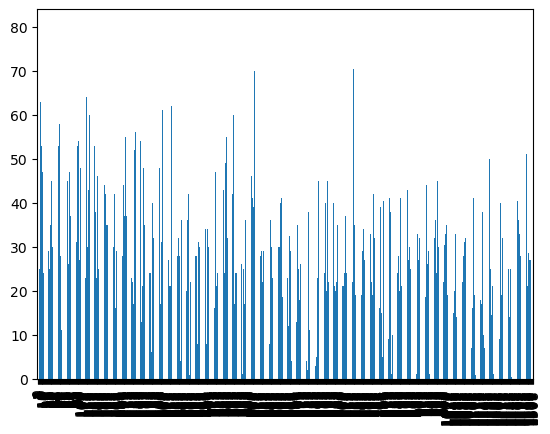

In [32]:
data['age'].plot.bar()

In [34]:
class_data = data['pclass'].value_counts()
class_data

pclass
3    501
1    284
2    261
Name: count, dtype: int64

# graphique des classes 

<Axes: ylabel='count'>

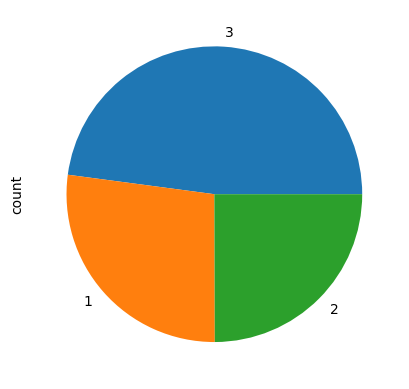

In [35]:
class_data.plot(kind='pie')

# Prediction de survivants : Machine learning

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
y = data['survived']
x= data.drop('survived', axis=1)

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [40]:
print(f"Nombre d'échantillons d'entraînement : {len(x_train)}")
print(f"Nombre d'échantillons de test : {len(x_test)}")

Nombre d'échantillons d'entraînement : 836
Nombre d'échantillons de test : 210


# choix du model: regression logistique

probleme de classification (survivant ou non survivant)

In [42]:
data['sex'] = data['sex'].map({'female': 0, 'male': 1})

In [48]:
# Séparation des caractéristiques (X) et de la cible (y)
X = data[['pclass', 'sex', 'age']]
y = data['survived']

In [59]:
# Division en train/test (80% / 20%)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ENTRAINEMENT

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [61]:
model_rf = RandomForestClassifier(n_estimators=1000, random_state=42)
model_rf.fit(X_train, y_train)

,n_estimators,1000
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
y_pred = model_rf.predict(X_test)
print(f"Précision du modèle : {accuracy_score(y_test, y_pred):.2%}")

Précision du modèle : 72.38%


# Test du  scenario

In [78]:
# [pclass, sex, age] -> [3, 1, 22]
test_passager = np.array([[1, 2, 17]])
survie = model_rf.predict(test_passager)

print("Survie prédite :" , "Oui" if survie[0] == 1 else "Non")

Survie prédite : Oui


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


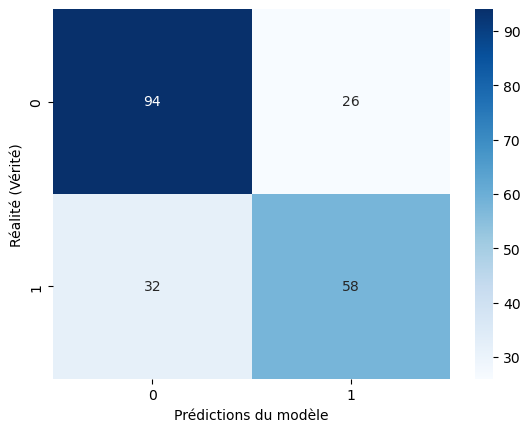

              precision    recall  f1-score   support

           0       0.75      0.78      0.76       120
           1       0.69      0.64      0.67        90

    accuracy                           0.72       210
   macro avg       0.72      0.71      0.72       210
weighted avg       0.72      0.72      0.72       210



In [73]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Générer la matrice
cm = confusion_matrix(y_test, y_pred)

# L'afficher proprement
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédictions du modèle')
plt.ylabel('Réalité (Vérité)')
plt.show()

# Afficher le rapport détaillé (Précision et Rappel)
print(classification_report(y_test, y_pred))